# Pedestrian Collision Severity and Urban Greenspace Accessibility in London

## Preface

- GitHub Repository: [View link](https://github.com/christychoicc/DSSS_Coursework)

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

- Declaration: LLM is used for fixing coding and grammar mistakes. 

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

What is the urban problem? Why greenspace accessibility? What is the analytical contribution? What can this study not claim? 


Pedestrian injury remains a key challenge for urban transport safety because pedestrians are especially vulnerable to severe outcomes in road collisions. In dense cities such as London, pedestrian collision severity may be shaped by a combination of road characteristics, traffic conditions, pedestrian characteristics, and wider environmental context. While many road safety studies focus on traffic engineering and demographic factors, less attention has been given to whether neighbourhood environmental features such as greenspace accessibility are associated with the severity of pedestrian injuries.

## 2. Research Question

[[ go back to the top ]](#Table-of-contents)

Pedestrian safety is a major urban policy and public health concern because severe pedestrian injuries reflect not only traffic conditions, but also the interaction between road design, pedestrian behaviour, environmental context, and neighbourhood characteristics. This study focuses on pedestrian-involved collisions in London and examines whether urban greenspace accessibility contributes meaningful explanatory value beyond established collision and casualty factors. Therefore, this analysis aims to answer the following research questions: 

**RQ1** - What are the factors associated with fatal or serious pedestrian events in London? 

**RQ2** - To what extent does the distance to the nearest greenspace access point contributes to pedestrian collision severity in London, relative to other spatial and environmental factors?

## 3. Data

[[ go back to the top ]](#Table-of-contents)

In this section, relevant datasets are pre-processed, cleaned, and spatially linked to construct a London pedestrian-collision dataframe. Second, descriptive and spatial exploratory analysis is used to examine the distribution of severe outcomes and greenspace accessibility. Third, the prepared analytical dataset is used for later model-based analysis to assess whether greenspace accessibility remains relevant after accounting for other factors.

### 3.1. Data Evaluation

This analysis uses four datasets: 

1. **[Road Safety Collision data (2024)](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data)**  
   This dataset contains collision-level information including location, road characteristics, environmental conditions, and counts of vehicles and casualties.

2. **[Road Safety Casualty data (2024)](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data)**  
   This dataset contains casualty-level information including casualty severity, pedestrian movement, pedestrian location, age, sex, and area-level deprivation indicators.

3. **[OS Open Greenspace Access Point data](https://osdatahub.os.uk/data/downloads/open/OpenGreenspace?_gl=1*lcmfh4*_ga*ODk4MTE3Nzk4LjE3NzU1ODM0ODg.*_ga_59ZBN7DVBG*czE3NzU1ODM0ODckbzEkZzAkdDE3NzU1ODM2NDgkajYwJGwwJGgw)**  
   This dataset provides point locations representing publicly accessible greenspace access points.

4. **[London LSOA boundary data](https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9/)**  
   This dataset is used for spatial filtering to study area, mapping purposes.

The collision and casualty data are joined using a common variable `collision_index`. Greenspace accessibility distance is calculated from each pedestrian-involved collision location to the nearest greenspace access point.

### 3.2. Load Packages
The below shows packages to install and import for data pre-processing, manipulation and running the analysis: 

In [1]:
# Install SHAP package first
# %pip install shap

In [2]:
# Packages for data processing and analysis

# --------------------------------- Data Wrangling and EDA -----------------------------------
import numpy as np                    # mathematical operations
import pandas as pd                   # data manipulation
import geopandas as gpd               # spatial data manipulation
import matplotlib.pyplot as plt       # visualisation

import warnings                       # supress warnings
warnings.filterwarnings('ignore')     # ignore warnings 


# ------------------------------------ Machine Learning --------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier        # Random Forest - Classification
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ----------------------------------- Accuracy Assessment -------------------------------------
from sklearn.metrics import r2_score                       # R squared 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score


# ----------------------------------- Model Interpretation -------------------------------------
#%pip install shap
import shap           # SHAP for model interpretation

### 3.3. Data Loading

In [3]:
# Load Collision 2024
collision = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-collision-2024.csv", low_memory=False)

# Load Casualty 2024 
casualty = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-casualty-2024.csv", low_memory=False)

# Load Green Space data
greenspace = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/OS-Open-Greenspace-GB/GB_AccessPoint.shp")

# Load London LOSA boundary data
london_lsoa = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/london_LSOA_boundary/LSOA_2011_London_gen_MHW.shp")

In [4]:
# Data Inspection

# Inspect number of rows and columns for all dataset
print("Collision data shape:", collision.shape)
print("Casualty data shape:", casualty.shape)
print("Greenspace data shape:", greenspace.shape)
print("London LSOA shape:", london_lsoa.shape)

# Inspect CRS for greenspace and London boundary data
print("\nGreenspace CRS:", greenspace.crs)
print("London LSOA CRS:", london_lsoa.crs)

# Inspect column names for all dataset
print("\nCollision Column names:")
print(collision.columns.tolist())
print("\nCasualty Column names:")
print(casualty.columns.tolist())
print("\nGreenspace Column names:")
print(greenspace.columns.tolist())

Collision data shape: (100927, 44)
Casualty data shape: (128272, 23)
Greenspace data shape: (355296, 4)
London LSOA shape: (4835, 15)

Greenspace CRS: EPSG:27700
London LSOA CRS: PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.999601272],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Collision Column names:
['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'ti

### 3.4. Data Pre-processing 

#### 3.4.1. Data Cleaning
##### Filter Road Safety Data (Collision and Casualty):

In [5]:
# Define a selection of needed column names
# Select needed columns for collision data
collision_cols = [    
    'collision_index', 'longitude', 'latitude', 'police_force',
    'speed_limit', 'road_type', 'junction_detail', 'junction_control',
    'pedestrian_crossing', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'urban_or_rural_area', 'date', 'day_of_week',
    'time', 'local_authority_district', 'lsoa_of_accident_location', 
    'number_of_vehicles','number_of_casualties']

# Select neeeded columns for Casualty data
# casualty_severity and enhanced_casualty_severity is same thing but enhanced is more detailed, keep both first
casualty_cols = ["collision_index", "casualty_severity", 'casualty_type',
                 'pedestrian_location', 'pedestrian_movement', 'age_of_casualty', 
                 'sex_of_casualty', 'casualty_imd_decile', 'casualty_class'] 

# Filter to selected columns
collision_filtered = collision[collision_cols]
casualty_filtered = casualty[casualty_cols]
print(f"Filtered columns collision: {collision_filtered.shape}")
print(f"Filtered columns casualty: {casualty_filtered.shape}")

Filtered columns collision: (100927, 20)
Filtered columns casualty: (128272, 9)


In [6]:
# Filter collision data to London only
# This uses the police_force column to select London, 
# where 1 = Metropolitan (excluding City of London) and 48 = City of London
london_collision = collision_filtered[collision_filtered['police_force'].isin([1, 48])]
print("London only collisions:", london_collision.shape)

# Filter casualty data to pedestrian only
# where casualty_type = 0 = pedestrian
pedestrian_casualty = casualty_filtered[casualty_filtered['casualty_type'] == 0]
print("Pedestrian only casualties:", pedestrian_casualty.shape)

# Using pedestrian casualty to filter pedestrian involved collisions
# Filter collisions index that involves pedestrian only
pedestrian_collision_index = pedestrian_casualty['collision_index'].unique()

# Filter to London pedestrian collisions only
london_pedestrian_collision = london_collision[london_collision['collision_index'].isin(pedestrian_collision_index)].copy()
print("London Pedestrian only collisions: ", london_pedestrian_collision.shape)

London only collisions: (21000, 20)
Pedestrian only casualties: (19176, 9)
London Pedestrian only collisions:  (4305, 20)


The binary variable is defined as:

- **1 = fatal or serious pedestrian outcome**
- **0 = slight pedestrian outcome**

At collision level, a collision is coded as 1 if any pedestrian casualty in that collision was recorded as fatal or serious. This approach captures whether a collision resulted in a severe pedestrian outcome, but it also requires careful handling of pedestrian-level explanatory variables when multiple pedestrian casualties are present in the same collision.

In [7]:
# Order casualty by severity
# casualty_severity: 1 = fatal, 2 = serious, 3 = slight
pedestrian_casualty_sorted = pedestrian_casualty.sort_values(
    by=['collision_index', 'casualty_severity']
).copy()

# Create collision-level severity 
# 1 for fatal or serious, otherwise 0
severity_by_collision = (
    pedestrian_casualty.groupby('collision_index')['casualty_severity']
    .min()
    .reset_index()
)
severity_by_collision['severity_binary'] = np.where(
    severity_by_collision['casualty_severity'] <= 2, 1, 0
)
severity_by_collision = severity_by_collision[
    ['collision_index', 'severity_binary']
].copy()

# Extract pedestrian attributes from the most severe pedestrian casualty in each collision
most_severe_pedestrian = (
    pedestrian_casualty_sorted
    .drop_duplicates(subset='collision_index', keep='first')
    .copy()
)

most_severe_pedestrian = most_severe_pedestrian[
    ['collision_index', 'pedestrian_location', 'pedestrian_movement',
     'age_of_casualty', 'sex_of_casualty', 'casualty_class',
     'casualty_imd_decile']].copy()

# Merge collision-level severity with the most severe pedestrian attributes
pedestrian_summary = severity_by_collision.merge(
    most_severe_pedestrian,
    on='collision_index',
    how='left'
)

# Merge with London pedestrian collision data
df_merged = london_pedestrian_collision.merge(
    pedestrian_summary,
    on='collision_index',
    how='inner'
)

print("Merged analytical dataset shape:", df_merged.shape)
df_merged.head()

Merged analytical dataset shape: (4305, 27)


,collision_index,longitude,latitude,police_force,speed_limit,road_type,junction_detail,junction_control,pedestrian_crossing,light_conditions,...,lsoa_of_accident_location,number_of_vehicles,number_of_casualties,severity_binary,pedestrian_location,pedestrian_movement,age_of_casualty,sex_of_casualty,casualty_class,casualty_imd_decile
0,2024010523519,0.15746,51.54594,1,30,6,0,-1,0,1,...,E01000015,2,1,0,9,5,59,2,3,6
1,2024010539849,0.12075,51.55111,1,30,6,0,-1,17,1,...,E01000024,1,1,1,1,1,15,2,3,3
2,2024010545768,0.13515,51.54781,1,30,6,19,4,17,1,...,E01000080,1,4,0,4,3,12,2,3,3
3,2024010544894,-0.35191,51.56551,1,30,6,0,-1,0,4,...,E01034600,1,1,1,5,3,64,1,3,7
4,2024010548442,0.15189,51.55012,1,30,6,0,-1,0,1,...,E01000016,1,1,0,9,6,5,1,3,2


In [8]:
# Create an hour column
df_merged['hour'] = pd.to_datetime(df_merged['time'], format='%H:%M').dt.hour

print("Merged data:", df_merged.shape)
print("\nColumn names: \n")
print(df_merged.columns.tolist())

Merged data: (4305, 28)

Column names: 

['collision_index', 'longitude', 'latitude', 'police_force', 'speed_limit', 'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'date', 'day_of_week', 'time', 'local_authority_district', 'lsoa_of_accident_location', 'number_of_vehicles', 'number_of_casualties', 'severity_binary', 'pedestrian_location', 'pedestrian_movement', 'age_of_casualty', 'sex_of_casualty', 'casualty_class', 'casualty_imd_decile', 'hour']


##### Filter OS Open Greenspace Access Point Data (Greenspace): 

In [9]:
# Filter Greenspace data to London only
london_boundary = london_lsoa.dissolve()
# Ensure consistent CRS
greenspace = greenspace.to_crs(london_boundary.crs)
# Clip greenspace to the exact London boundary
greenspace_london = gpd.clip(greenspace, london_boundary)

In [10]:
# Transform geometry column's point(x y z) into normal point(x y) only
# Code derived from LLM (Claude AI)
from shapely.geometry import Point

greenspace_london['geometry'] = greenspace_london['geometry'].apply(
    lambda g: Point(g.x, g.y)  # drops Z, keeps X and Y only
)

# Check
#print(greenspace_london.geometry.iloc[0])

In [11]:
# Join london_pedestrian_collision and london_greenspace

# Convert collision df to GeoDataFrame
gdf_collisions = gpd.GeoDataFrame(
    df_merged,
    geometry=gpd.points_from_xy(df_merged['longitude'], 
                                df_merged['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:27700')  # reproject to match greenspace CRS

# Calculate distance to the nearest greenspace access point
join = gpd.sjoin_nearest(
    gdf_collisions,
    greenspace_london[['geometry']],
    how='left',
    distance_col='green_access_distance'
)

# Add distance to df
df_merged['green_access_distance'] = join['green_access_distance'].values

#### 3.4.2. Merge Dataframes

In [12]:
# Extract needed columns
clean_cols = [
    'collision_index', 'longitude', 'latitude',
    'speed_limit', 'road_type', 'junction_detail', 'junction_control',
    'pedestrian_crossing', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'urban_or_rural_area', 'day_of_week',
    'date', 'hour', 'local_authority_district', 'lsoa_of_accident_location',
    'number_of_vehicles', 'number_of_casualties',
    'pedestrian_location', 'pedestrian_movement',
    'age_of_casualty', 'sex_of_casualty', 'casualty_class',
    'casualty_imd_decile','green_access_distance', 'severity_binary'
]

# Cleaned df: 
df_merged_joined = df_merged[clean_cols].copy()

In [13]:
# Check the distribution of data for assigning suitable bands
df_clean = df_merged_joined.copy()
df_clean['green_access_distance'].describe()

count    4305.000000
mean      163.186052
std       115.672147
min         1.332926
25%        80.092442
50%       144.842679
75%       221.858075
max      1342.249477
Name: green_access_distance, dtype: float64

In [14]:
# Calculate suitable band ranges and create a new variable column
df_clean['green_distance_band'] = pd.cut(
    df_clean['green_access_distance'],
    # < 100 below 25 percentile
    # 100-200 median 
    # 200-300 around 75 percentile
    # > 300 as furthest range
    bins=[0, 100, 200, 300, np.inf],
    labels=['0-100m', '100-200m', '200-300m', '300m+']
)

# Log-transform distance for later modelling (helps with right-skew)
df_clean['log_green_access_distance'] = np.log1p(df_clean['green_access_distance'])

# Summary table for descriptive exploration
greenspace_band_summary = (
    df_clean.groupby('green_distance_band', observed=True)['severity_binary']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'severity_rate', 'count': 'n_collisions'})
)

greenspace_band_summary

,severity_rate,n_collisions
green_distance_band,,
0-100m,0.291050,1419
100-200m,0.272148,1569
200-300m,0.251174,852
300m+,0.279570,465


In [15]:
# Check columns
print(df_clean['green_distance_band'].value_counts())

green_distance_band
100-200m    1569
0-100m      1419
200-300m     852
300m+        465
Name: count, dtype: int64


#### 3.4.3. Wrangling Missing, Unknown or Others Data

|Variable|Description|Action|
|---|---|---|
|road_type| 9 (349 rows of unknown)|Keep as unknown|
|junction_detail|-1 (353 rows of missing)|Replace it as unkown|
|junction_control|-1 (1039 rows of missing); 9 (243 rows of unknown)|Replace it as unkown|
|weather_conditions|8 (239 rows of others); 9 (303 rows of unknown)|Keep as others/ unknown|
|road_surface_conditions|9 (212 rows of unknown)|Keep as unknown|
|pedestrian_crossing|99 (312 rows of unknown)|Keep as unknown|
|pedestrian_location|10 (415 rows of unknown)|Keep as unknown|
|pedestrian_movement |9 (1447 rows of unknown)|Keep as unknown|
|age_of_casualty |-1 (132 rows of missing)|Replace with median value|
|sex_of_casualty |-1 (38 rows of missing)|Replace it as unkown|

In [16]:
# Encode missing as unkown 
df_clean['junction_detail'] = df_clean['junction_detail'].replace(-1, 99)
df_clean['junction_control'] = df_clean['junction_control'].replace(-1, 9)
df_clean['sex_of_casualty'] = df_clean['sex_of_casualty'].replace(-1, 9)

# Continuous variable - replace with median for any unknown values
# Count of initial -1 counts
unknown_age_count = (df_clean['age_of_casualty'] == -1).sum()
print("Unknown age count before replacement:", unknown_age_count)
# Replacement of unknown to median age of data
median_age = df_clean.loc[df_clean['age_of_casualty'] != -1, 'age_of_casualty'].median()
print("Median age used for replacement:", median_age)

df_clean['age_of_casualty'] = df_clean['age_of_casualty'].replace(-1, median_age)
print("Unknown age count after replacement:", (df_clean['age_of_casualty'] == -1).sum())

Unknown age count before replacement: 130
Median age used for replacement: 35.0
Unknown age count after replacement: 0


### 3.5. Table of Variables
| Variable Name | Description | Data Type | Purpose |
|---|---|---|---|
|severity_binary |Collision severity outcome: 1 = fatal/serious pedestrian casualty, 0 = slight pedestrian casualty |Binary |Target |
|green_access_distance |Distance from collision location to nearest greenspace access point (meters) |Numeric | |
|green_distance_band|Grouped version of greenspace distance: 0–100m, 100–200m, 200–300m, 300m+|Categorical||
|speed_limit |Speed limit at collision location (mph) |Categorical | |
|road_type |Type of road where collision occurred |Categorical | |
|junction_detail |Type of junction at collision location |Categorical | |
|junction_control |Control type at junction|Categorical | |
|light_conditions |Lighting condition at time of collision |Categorical | |
|weather_conditions |Weather condition at time of collision |Categorical | |
|road_surface_conditions |Condition of road surface at collision location |Categorical | |
|urban_or_rural_area |Condition of road surface at collision location |Categorical | |
|day_of_week|Day of the week when collision occurred |Categorical | |
|pedestrian_location |Location of pedestrian relative to road or crossing |Categorical | |
|pedestrian_crossing |Type of pedestrian crossing facility present|Categorical | |
|date|Date of collision |Date | |
|hour |Hour of day extracted from collision time |Numeric | |
|collision_index|Unique collision identifier|ID||
|longitude|Longitude coordinate of collision location|Geometry||
|latitude|Latitude coordinate of collision location|Geometry||
|local_authority_district |Local authority district code of collision location |Categorical | |
|lsoa_of_accident_location |LSOA code of collision location |ID | |
|number_of_vehicles|Number of vehicles involved in the collision|Numeric||
|number_of_casualties|Number of casualties recorded in the collision|Numeric||
|pedestrian_movement||||
|age_of_casualty|Age of pedestrian casualty in years|Numeric||
|sex_of_casualty|Sex of pedestrian casualty|Categorical||
|casualty_class||||
|casualty_imd_decile|Deprivation decile of casualty area|||

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

### 4.1. Exploratory Analysis

##### Slight vs Fatal/Serious Collisions

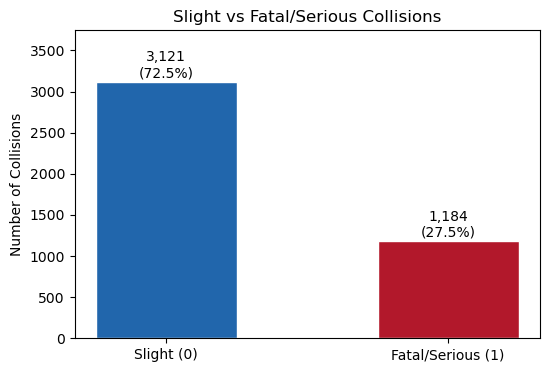

In [17]:
# Slight vs Fatal/ Severity
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_clean['severity_binary'].value_counts().sort_index()
bars = ax.bar(['Slight (0)', 'Fatal/Serious (1)'], counts.values,
              color=['#2166AC', '#B2182B'], edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{count:,}\n({count/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Slight vs Fatal/Serious Collisions',
             fontsize=12)
ax.set_ylabel('Number of Collisions')
ax.set_ylim(0, counts.max() * 1.2)

plt.show()

##### Collision Counts and Fatal/Serious Rate by Greenspace Distance Band

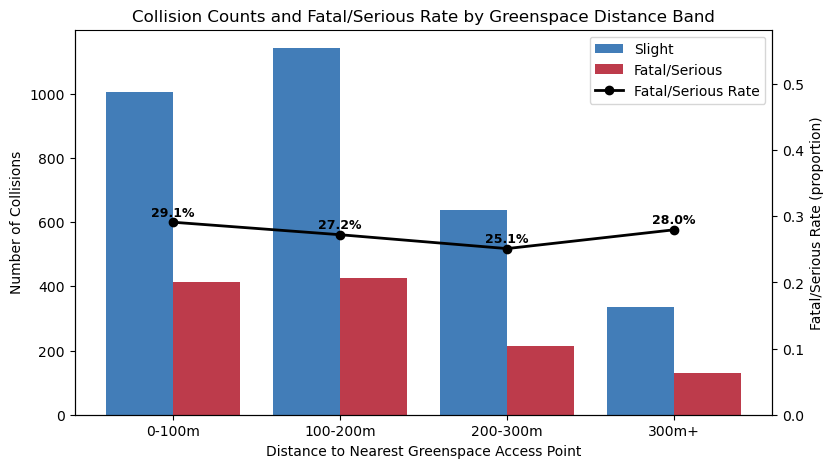

In [18]:
# Collision Count by Distance Band

# Groupby collisions by distance bands and severity band
band_detail = (df_clean.groupby(['green_distance_band', 'severity_binary'], observed=True)
               .size()
               .reset_index(name='count'))

# Extract slight collisions
slight_counts    = band_detail[band_detail['severity_binary'] == 0].set_index('green_distance_band')['count']
# Extract serious (fatal/serious) collisions
fatalserious_counts   = band_detail[band_detail['severity_binary'] == 1].set_index('green_distance_band')['count']

# Compute severity rate per band, rename columns
band_summary = greenspace_band_summary .rename(columns={'Severity Rate': 'severity_rate', 'Count': 'total'})
# Set order of bands
bands_order = ['0-100m', '100-200m', '200-300m', '300m+']
x = range(len(bands_order))
width = 0.4

# Plot Graph
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

# Slight bands
ax1.bar([i - width/2 for i in x],
        [slight_counts.get(b, 0) for b in bands_order],
        width=width, color='#2166AC', label='Slight', alpha=0.85)
# Serious (fatal/serious) bands
ax1.bar([i + width/2 for i in x],
        [fatalserious_counts.get(b, 0) for b in bands_order],
        width=width, color='#B2182B', label='Fatal/Serious', alpha=0.85)

# Create severity rate for each distance band --> using band_summary
severity_rates = [band_summary.loc[b, 'severity_rate'] if b in band_summary.index else 0 for b in bands_order]

# Plot severity line on graph
ax2.plot(list(x), severity_rates, color='black', linewidth=2, marker='o',
         markersize=6, label='Fatal/Serious Rate', zorder=5)
# Add percentage above each point of severity
for i, r in enumerate(severity_rates):
    ax2.text(i, r + 0.005, f'{r:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(list(x))
ax1.set_xticklabels(bands_order)
ax1.set_xlabel('Distance to Nearest Greenspace Access Point')
ax1.set_ylabel('Number of Collisions')
ax2.set_ylabel('Fatal/Serious Rate (proportion)', color='black')
ax2.set_ylim(0, max(severity_rates) * 2)
ax1.set_title('Collision Counts and Fatal/Serious Rate by Greenspace Distance Band',
              fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.spines[['top']].set_visible(False)

plt.show()

##### Average Speed Limit by Greenspace Distance Band

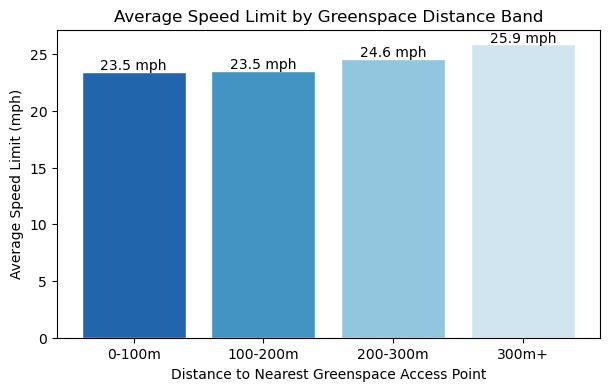

In [19]:
# Speed limit by greenspace distance band

# Groupby distance bands with speed limit
speed_band = df_clean.groupby('green_distance_band', observed=True)['speed_limit'].mean()

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(speed_band.index, speed_band.values,
       color=['#2166AC', '#4393C3', '#92C5DE', '#D1E5F0'],
       edgecolor='white')

# Add speed limit above each bar 
for i, (band, val) in enumerate(speed_band.items()):
    ax.text(i, val + 0.2, f'{val:.1f} mph', ha='center', fontsize=10)

ax.set_title('Average Speed Limit by Greenspace Distance Band',
             fontsize=12)
ax.set_xlabel('Distance to Nearest Greenspace Access Point')
ax.set_ylabel('Average Speed Limit (mph)')

plt.show()

##### Distribution of Distance to Nearest Greenspace Access Point

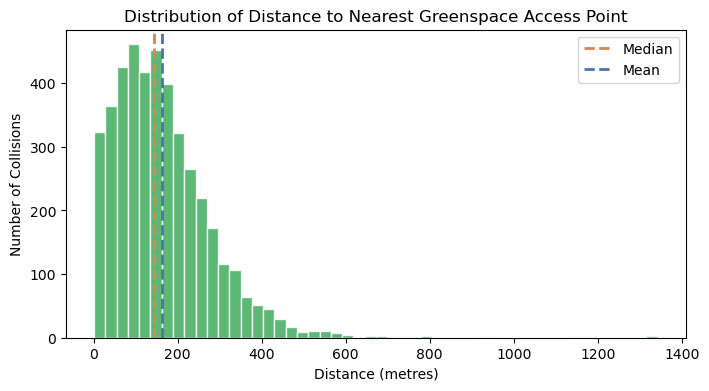

In [20]:
# Distribution of distance to greenspace
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean['green_access_distance'], bins=50,
        color='#41AB5D', edgecolor='white', alpha=0.85)

# Add median line on graph
ax.axvline(df_clean['green_access_distance'].median(), color='#DD8452',
           linewidth=2, linestyle='--',
           label="Median")

# Add mean line on graph
ax.axvline(df_clean['green_access_distance'].mean(), color='#4C72B0',
           linewidth=2, linestyle='--',
           label="Mean")

ax.set_title('Distribution of Distance to Nearest Greenspace Access Point',
             fontsize=12)
ax.set_xlabel('Distance (metres)')
ax.set_ylabel('Number of Collisions')
ax.legend()

plt.show()

##### Pedestrian Collision Severity Rate by London LSOA

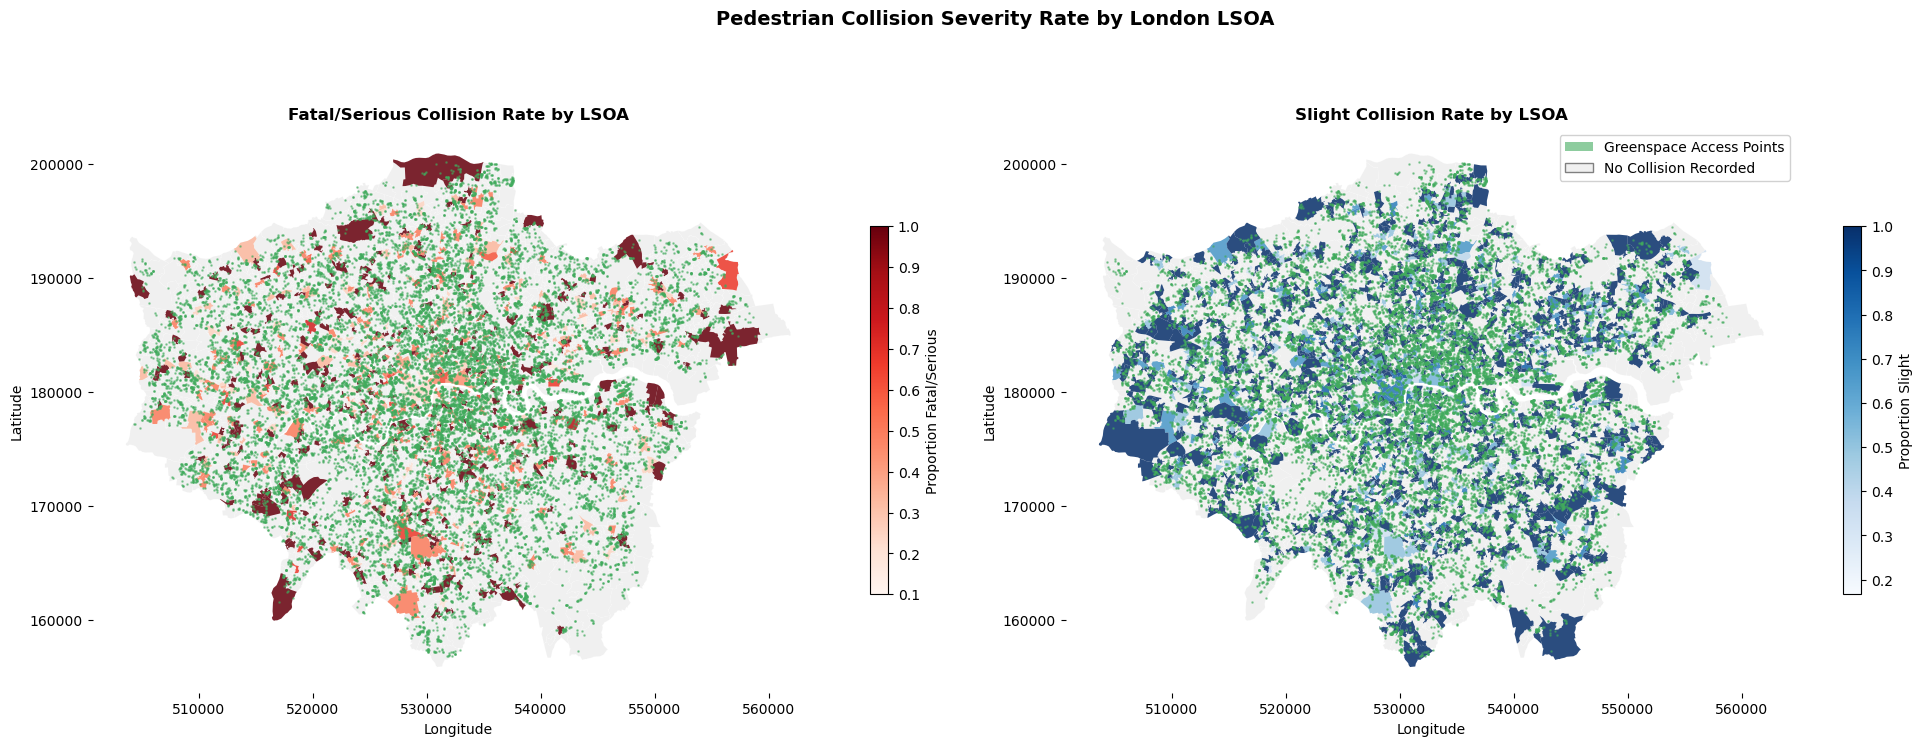

In [21]:
# Pedestrian Collision Severity Rate by London LSOA with Greenspace Access Point

# Ensure projection is consistent with greenspace dataset CRS
london_lsoa = london_lsoa.to_crs('EPSG:27700')

# Clip greenspace to london_lsoa boundary
greenspace_clipped = gpd.clip(greenspace, london_lsoa)

# Calculate fatal/serious rate per LSOA
# 1. Count fatal serious collisions per LSOA
fatalserious_counts2 = (df_clean[df_clean['severity_binary'] == 1]
               .groupby('lsoa_of_accident_location').size())
# 2. Count all collisions per LSOA
total_count = (df_clean.groupby('lsoa_of_accident_location').size())
# 3. Calculate rate
rate_fs = (fatalserious_counts2 / total_count).reset_index()
rate_fs.columns = ['LSOA11CD', 'severity_rate']
lsoa_fs = london_lsoa.merge(rate_fs, on='LSOA11CD', how='left')

# Calculate slight rate per LSOA
slight_count2 = (df_clean[df_clean['severity_binary'] == 0]
                .groupby('lsoa_of_accident_location').size())
rate_sl = (slight_count2 / total_count).reset_index()
rate_sl.columns = ['LSOA11CD', 'slight_rate']
lsoa_sl = london_lsoa.merge(rate_sl, on='LSOA11CD', how='left')

# Plot map
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left side — Fatal/Serious
london_lsoa.plot(ax=axes[0], color='#F0F0F0', edgecolor='white', linewidth=0.1)
lsoa_fs[lsoa_fs['severity_rate'].notna()].plot(
    ax=axes[0], column='severity_rate', cmap='Reds',
    edgecolor='none', alpha=0.85, legend=True,
    legend_kwds={'label': 'Proportion Fatal/Serious',
                 'orientation': 'vertical', 'shrink': 0.5}
)
greenspace_clipped.plot(ax=axes[0], color='#41AB5D', markersize=0.8, alpha=0.5)
axes[0].set_title('Fatal/Serious Collision Rate by LSOA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].spines[['top','right','left','bottom']].set_visible(False)

# Right side — Slight
london_lsoa.plot(ax=axes[1], color='#F0F0F0', edgecolor='white', linewidth=0.1)
lsoa_sl[lsoa_sl['slight_rate'].notna()].plot(
    ax=axes[1], column='slight_rate', cmap='Blues',
    edgecolor='none', alpha=0.85, legend=True,
    legend_kwds={'label': 'Proportion Slight',
                 'orientation': 'vertical', 'shrink': 0.5}
)
greenspace_clipped.plot(ax=axes[1], color='#41AB5D', markersize=0.8, alpha=0.5)
axes[1].set_title('Slight Collision Rate by LSOA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].spines[['top','right','left','bottom']].set_visible(False)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#41AB5D', alpha=0.6, label='Greenspace Access Points'),
    Patch(facecolor='#F0F0F0', edgecolor='grey', label='No Collision Recorded')
], loc='upper right', framealpha=0.9)

fig.suptitle('Pedestrian Collision Severity Rate by London LSOA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Methodology

### 4.1. Decision Tree Classification (Baseline)

In [22]:
# Select features for modelling
feature_cols_dt = [
    'green_access_distance', 'speed_limit', 'road_type',
    'junction_detail', 'junction_control', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week', 'hour',
    'pedestrian_location', 'pedestrian_movement',
    'age_of_casualty', 'sex_of_casualty', 'casualty_class',
    'number_of_vehicles', 'number_of_casualties'
]
X_dt = df_clean[feature_cols_dt].copy()
y_dt = df_clean['severity_binary'].copy()

cat_cols_dt = [
    'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week',
    'pedestrian_location', 'pedestrian_movement',
    'sex_of_casualty', 'casualty_class'
]
X_dt = pd.get_dummies(X_dt, columns=cat_cols_dt, drop_first=True)

# Train/ test split
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)
print(f"Train: {X_train_dt.shape[0]} rows; Test: {X_test_dt.shape[0]} rows")
print(f"Fatal/Serious rate - Train: {y_train_dt.mean():.2%}; Test: {y_test_dt.mean():.2%}")

# Set up parameters
param_grid_dt = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]  # LLM (Claude AI) suggested to add this
}
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)
grid_dt.fit(X_train_dt, y_train_dt)
print("Best hyperparameters:", grid_dt.best_params_)
print(f"Best CV F1: {grid_dt.best_score_:.3f}")
best_dt = grid_dt.best_estimator_

# Train test evaluation
y_train_pred_dt = best_dt.predict(X_train_dt)
y_test_pred_dt = best_dt.predict(X_test_dt)
y_test_prob_dt = best_dt.predict_proba(X_test_dt)[:, 1]

train_recall_dt = recall_score(y_train_dt, y_train_pred_dt)
test_recall_dt = recall_score(y_test_dt, y_test_pred_dt)
train_accuracy_dt = accuracy_score(y_train_dt, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test_dt, y_test_pred_dt)

print(f"Train recall: {train_recall_dt:.3f}")
print(f"Test recall: {test_recall_dt:.3f}")
print(f"Train accuracy: {train_accuracy_dt:.3f}")
print(f"Test accuracy: {test_accuracy_dt:.3f}")

print("\nDecision Tree Performance")
print(f"Accuracy : {accuracy_score(y_test_dt, y_test_pred_dt):.3f}")
print(f"Precision: {precision_score(y_test_dt, y_test_pred_dt):.3f}")
print(f"Recall   : {recall_score(y_test_dt, y_test_pred_dt):.3f}")
print(f"F1-score : {f1_score(y_test_dt, y_test_pred_dt):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_dt, y_test_prob_dt):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test_dt, y_test_prob_dt):.3f}\n")
print(classification_report(y_test_dt, y_test_pred_dt, target_names=['Slight', 'Fatal/Serious']))

# Save as dictionary
dt_results = {
    'CV_F1': grid_dt.best_score_,
    'Train_Recall': train_recall_dt,
    'Test_Recall': test_recall_dt,
    'Train_Accuracy': train_accuracy_dt,
    'Test_Accuracy': test_accuracy_dt,
    'Test_ROC_AUC': roc_auc_score(y_test_dt, y_test_prob_dt),
    'Test_PR_AUC': average_precision_score(y_test_dt, y_test_prob_dt)
}

Train: 3444 rows; Test: 861 rows
Fatal/Serious rate - Train: 27.50%; Test: 27.53%
Best hyperparameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV F1: 0.451
Train recall: 0.584
Test recall: 0.456
Train accuracy: 0.690
Test accuracy: 0.641

Decision Tree Performance
Accuracy : 0.641
Precision: 0.375
Recall   : 0.456
F1-score : 0.411
ROC-AUC  : 0.598
PR-AUC   : 0.334

               precision    recall  f1-score   support

       Slight       0.77      0.71      0.74       624
Fatal/Serious       0.38      0.46      0.41       237

     accuracy                           0.64       861
    macro avg       0.57      0.58      0.58       861
 weighted avg       0.66      0.64      0.65       861



### 4.2. Random Forest Classification

In [23]:
# Set up features for random forest
feature_cols_rf = [
    'green_access_distance', 'speed_limit', 'road_type',
    'junction_detail', 'junction_control', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week', 'hour',
    'pedestrian_location', 'pedestrian_movement',
    'age_of_casualty', 'sex_of_casualty', 'casualty_class',
    'number_of_vehicles', 'number_of_casualties'
]
X_rf = df_clean[feature_cols_rf].copy()
y_rf = df_clean['severity_binary'].copy()

cat_cols_rf = [
    'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week',
    'pedestrian_location', 'pedestrian_movement',
    'sex_of_casualty', 'casualty_class'
]
X_rf = pd.get_dummies(X_rf, columns=cat_cols_rf, drop_first=True)

# Train/ val/ test split
X_trainval_rf, X_test_rf, y_trainval_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_trainval_rf, y_trainval_rf, test_size=0.25, random_state=42, stratify=y_trainval_rf
)
print(f"Train: {X_train_rf.shape[0]} rows")
print(f"Validation: {X_val_rf.shape[0]} rows")
print(f"Test: {X_test_rf.shape[0]} rows")
print(f"Severity rate - Train: {y_train_rf.mean():.2%}; Val: {y_val_rf.mean():.2%}; Test: {y_test_rf.mean():.2%}")

# Set up parameters
param_grid_rf = {
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 1.0],
    'class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]  # LLM (Claude AI) suggested to add this
}
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)
grid_rf.fit(X_train_rf, y_train_rf)
print("Best hyperparameters:", grid_rf.best_params_)
print(f"Best CV F1: {grid_rf.best_score_:.3f}")
best_rf = grid_rf.best_estimator_

# Tuning --> find best threshold
val_probs_rf = best_rf.predict_proba(X_val_rf)[:, 1]
# thresholds_rf = np.arange(0.1, 1.0, 0.1) change to: 
thresholds_rf = np.arange(0.1, 0.9, 0.05)
threshold_rows_rf = []
for th in thresholds_rf:
    val_pred_rf = (val_probs_rf >= th).astype(int)
    threshold_rows_rf.append({
        'threshold': th,
        'precision': precision_score(y_val_rf, val_pred_rf, zero_division=0),
        'recall': recall_score(y_val_rf, val_pred_rf, zero_division=0),
        'f1': f1_score(y_val_rf, val_pred_rf, zero_division=0)
    })
threshold_df_rf = pd.DataFrame(threshold_rows_rf)

# Choose threshold by best validation F1
best_threshold_rf = threshold_df_rf.loc[threshold_df_rf['f1'].idxmax(), 'threshold']
print(f"Selected threshold based on validation F1: {best_threshold_rf:.2f}")

best_rf.fit(X_trainval_rf, y_trainval_rf)

# Train/ test evaluation
train_pred_rf = best_rf.predict(X_train_rf)
test_probs_rf = best_rf.predict_proba(X_test_rf)[:, 1]
test_pred_rf = (test_probs_rf >= best_threshold_rf).astype(int)

train_recall_rf = recall_score(y_train_rf, train_pred_rf)
test_recall_rf = recall_score(y_test_rf, test_pred_rf)
train_accuracy_rf = accuracy_score(y_train_rf, train_pred_rf)
test_accuracy_rf = accuracy_score(y_test_rf, test_pred_rf)

print(f"Train recall: {train_recall_rf:.3f}")
print(f"Test recall: {test_recall_rf:.3f}")
print(f"Train accuracy: {train_accuracy_rf:.3f}")
print(f"Test accuracy: {test_accuracy_rf:.3f}")

print("\nRandom Forest Performance (Threshold-tuned)")
print(f"Accuracy : {accuracy_score(y_test_rf, test_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test_rf, test_pred_rf):.3f}")
print(f"Recall   : {recall_score(y_test_rf, test_pred_rf):.3f}")
print(f"F1-score : {f1_score(y_test_rf, test_pred_rf):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_rf, test_probs_rf):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test_rf, test_probs_rf):.3f}\n")
print(classification_report(y_test_rf, test_pred_rf, target_names=['Slight', 'Fatal/Serious']))

# Save as dictionary
rf_clf_results = {
    'CV_F1': grid_rf.best_score_,
    'Threshold': best_threshold_rf,
    'Train_Recall': train_recall_rf,
    'Test_Recall': test_recall_rf,
    'Train_Accuracy': train_accuracy_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_Precision': precision_score(y_test_rf, test_pred_rf),
    'Test_F1': f1_score(y_test_rf, test_pred_rf),
    'Test_ROC_AUC': roc_auc_score(y_test_rf, test_probs_rf),
    'Test_PR_AUC': average_precision_score(y_test_rf, test_probs_rf)
}

Train: 2583 rows
Validation: 861 rows
Test: 861 rows
Severity rate - Train: 27.49%; Val: 27.53%; Test: 27.53%
Best hyperparameters: {'class_weight': {0: 1, 1: 3}, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2}
Best CV F1: 0.479
Selected threshold based on validation F1: 0.50
Train recall: 0.842
Test recall: 0.709
Train accuracy: 0.591
Test accuracy: 0.524

Random Forest Performance (Threshold-tuned)
Accuracy : 0.524
Precision: 0.330
Recall   : 0.709
F1-score : 0.450
ROC-AUC  : 0.636
PR-AUC   : 0.399

               precision    recall  f1-score   support

       Slight       0.80      0.45      0.58       624
Fatal/Serious       0.33      0.71      0.45       237

     accuracy                           0.52       861
    macro avg       0.57      0.58      0.52       861
 weighted avg       0.67      0.52      0.54       861



### 4.3. SHAP Model Interpretation


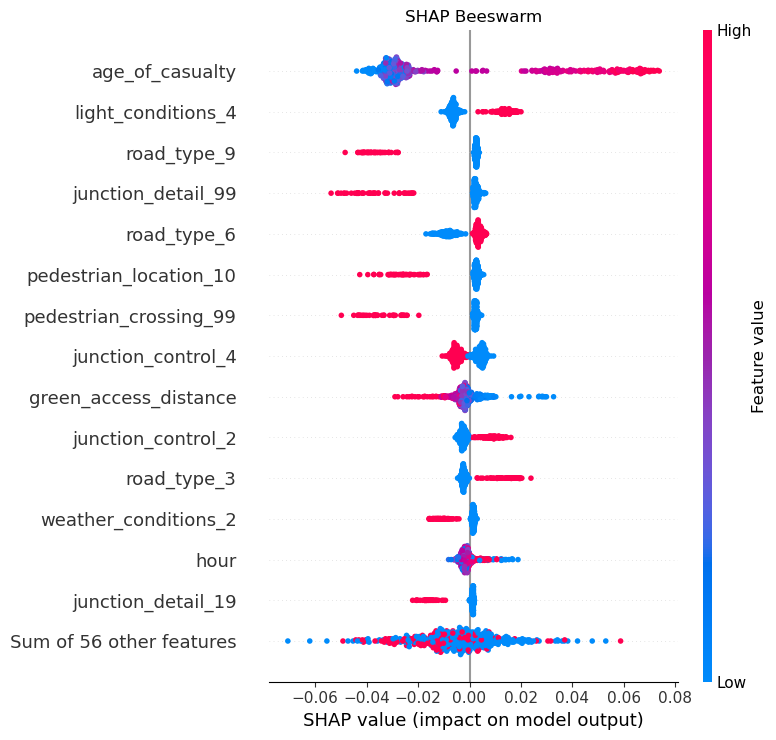

In [24]:
# Sample test set for speed (REFINED WITH ONE HOT ENCODING)
X_shap = X_test_rf.sample(n=min(500, len(X_test_rf)), random_state=42)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_shap)

shap.plots.beeswarm(shap_values[:, :, 1], max_display=15, show=False)
plt.title('SHAP Beeswarm', fontsize=12)
plt.tight_layout()
plt.show()

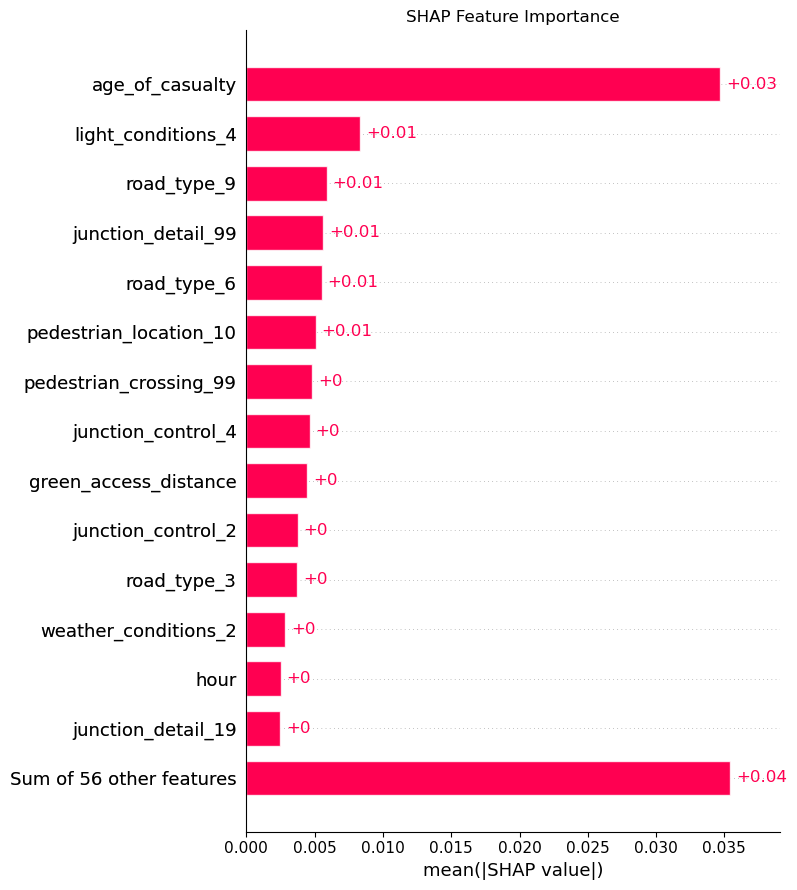

In [25]:
# Global bar plot
shap.plots.bar(shap_values[:, :, 1], max_display=15, show=False)
plt.title('SHAP Feature Importance', fontsize=12)
plt.tight_layout()
plt.show()

Age of casualty was the strongest predictor for pedestrian collision severity, where older pedestrians maybe exposed to higher vulnerability which leads do more severe injuries. While age is a demographic factor, it was retained in the model with road and environmental variables, as removing the variable may risk confounding the contribution of other variables.

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

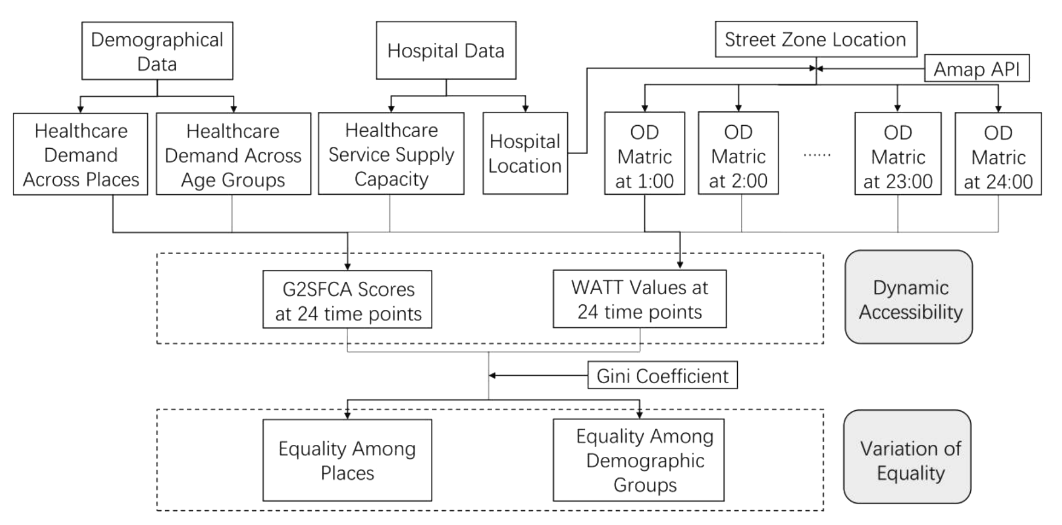

## 5. Results and discussion

[[ go back to the top ]](#Table-of-contents)

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

## 7. References

[[ go back to the top ]](#Table-of-contents)